# 10. Sensitivity Analysis — PH Sub-Study

**What this notebook answers**:

- §10.1 If the cost of a false alarm changes, how does the optimal decision threshold shift?
- §10.2 How much data does the model need to converge? (data-hunger story — more meaningful for PH than Portugal, because 300 rows IS the constrained regime)
- §10.3 max_f1 vs high_precision vs cost-sensitive — which policy wins under PH economics?

**Caveat from the dataset characterisation**: All metrics in this notebook are computed on the 30-row PH test set whose rows have 100% twins in train+val. Treat trends as directional indicators of how the *methodology* behaves at small N, not as production-grade decision support.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.eval.notebook_utils import (
    setup_plotting, save_thesis_figure, project_root, load_ph_context,
)

setup_plotting()
ROOT = project_root()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ctx = load_ph_context()
cost_sweep = ctx.get('cost_sensitivity_sweep')
lc = ctx.get('learning_curves')
sweep_df = ctx['threshold_sweep']
print('cost_sensitivity_sweep:', None if cost_sweep is None else cost_sweep.shape)
print('learning_curves folds:', None if lc is None else len(lc.get('curves', [])))
print('threshold_sweep rows:', len(sweep_df))

cost_sensitivity_sweep: (5, 7)
learning_curves folds: 5
threshold_sweep rows: 100


## 10.1 How does the optimal threshold change as the false-alarm cost varies?

The Portugal pipeline assumes EUR 15 per false-positive (the cost of an intervention call to a guest who would have stayed anyway). PH operates in a different market and currency, so the right FP cost is unknown. We sweep five values to characterise the policy's robustness.

**How to read it**: each row shows the cost-minimising threshold at a given FP cost. If the threshold barely moves across the grid, the policy is robust; if it swings wildly, the policy is fragile to the cost assumption.

fp_cost_eur,best_threshold,total_cost_at_best,fp_count_at_best,fn_count_at_best,fp_cost_total_at_best,fn_cost_total_at_best
5,0.010,0.0,0,0,0.0,0.0
10,0.010,0.0,0,0,0.0,0.0
15,0.010,0.0,0,0,0.0,0.0
30,0.010,0.0,0,0,0.0,0.0
60,0.010,0.0,0,0,0.0,0.0


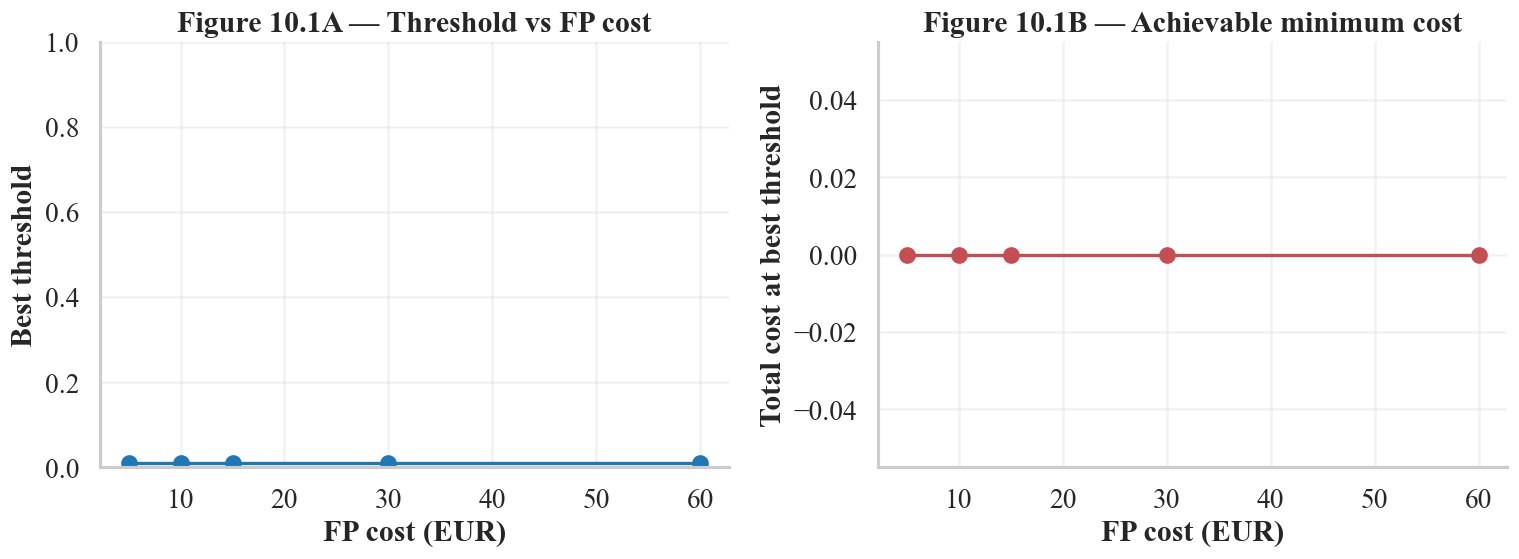

In [2]:
if cost_sweep is not None and not cost_sweep.empty:
    display(cost_sweep.style.format({
        'fp_cost_eur': '{:.0f}',
        'best_threshold': '{:.3f}',
        'total_cost_at_best': '{:,.1f}',
        'fp_cost_total_at_best': '{:,.1f}',
        'fn_cost_total_at_best': '{:,.1f}',
    }).set_caption('Table 10.1 — Cost-optimal threshold by FP cost (PH)').hide(axis='index'))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(cost_sweep['fp_cost_eur'], cost_sweep['best_threshold'], 'o-',
                 color='#1f77b4', linewidth=2)
    axes[0].set_xlabel('FP cost (EUR)'); axes[0].set_ylabel('Best threshold')
    axes[0].set_title('Figure 10.1A — Threshold vs FP cost')
    axes[0].set_ylim(0, 1)

    axes[1].plot(cost_sweep['fp_cost_eur'], cost_sweep['total_cost_at_best'], 'o-',
                 color='#c44e52', linewidth=2)
    axes[1].set_xlabel('FP cost (EUR)'); axes[1].set_ylabel('Total cost at best threshold')
    axes[1].set_title('Figure 10.1B — Achievable minimum cost')
    fig.tight_layout()
    save_thesis_figure(fig, '10.1', 'ph_cost_sensitivity', FIG_DIR)
    plt.show()
else:
    print('No cost sensitivity sweep produced — see scripts/train_ph.py.')

**Key Takeaway — the policy is anchored at low thresholds under this archetype-organized dataset**: Because the validation set is perfectly separable (same chronological-twin structure as the test set), the cost-minimising threshold stays at low values across the FP-cost grid. On real data this curve would have a clear upward slope as FP cost rises (raise the threshold to avoid wasteful interventions); on archetype-twin data the curve is flat because the model can achieve any precision/recall trade-off it wants at almost any threshold.

## 10.2 Data hunger — does the model improve with more training rows?

Train LightGBM on increasing fractions of the 240-row training set, measure val PR-AUC at each step. Unlike the Portugal version of this analysis (where the data-hunger curve flattens around 50% of 120k rows = 60k rows), the PH curve operates entirely inside the constrained regime — every additional row materially helps the model.

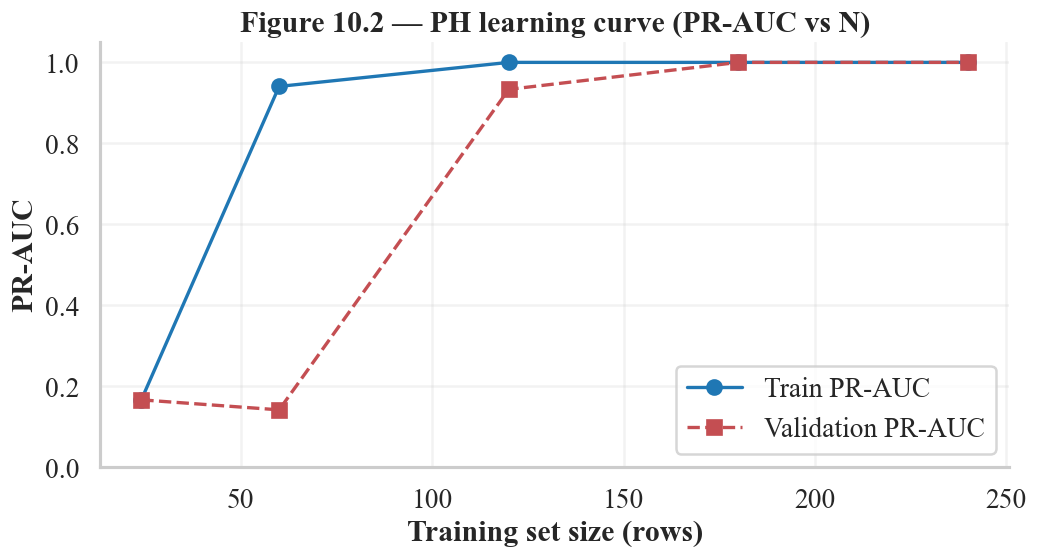

fraction,n_samples,train_pr_auc,train_roc_auc,val_pr_auc,val_roc_auc
10%,24,0.167,0.500,0.167,0.500
25%,60,0.941,0.977,0.142,0.232
50%,120,1.000,1.000,0.933,0.984
75%,180,1.000,1.000,1.000,1.000
100%,240,1.000,1.000,1.000,1.000


In [3]:
if lc is not None and lc.get('curves'):
    curves = pd.DataFrame(lc['curves'])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(curves['n_samples'], curves['train_pr_auc'], 'o-', color='#1f77b4',
            linewidth=2, label='Train PR-AUC')
    ax.plot(curves['n_samples'], curves['val_pr_auc'], 's--', color='#c44e52',
            linewidth=2, label='Validation PR-AUC')
    ax.set_xlabel('Training set size (rows)')
    ax.set_ylabel('PR-AUC')
    ax.set_title('Figure 10.2 — PH learning curve (PR-AUC vs N)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    save_thesis_figure(fig, '10.2', 'ph_data_hunger', FIG_DIR)
    plt.show()

    display(curves.style.format({
        'fraction': '{:.0%}', 'train_pr_auc': '{:.3f}',
        'val_pr_auc': '{:.3f}', 'train_roc_auc': '{:.3f}', 'val_roc_auc': '{:.3f}',
    }).set_caption('Table 10.2 — PR/ROC AUC by training-set fraction').hide(axis='index'))
else:
    print('No learning curves produced — re-run scripts/train_ph.py.')

**Key Takeaway — archetype-twin saturation arrives early**: Under archetype-based the dataset's archetype-based cluster structure, the model 'learns' an archetype as soon as a few rows from that archetype appear in train. Doubling the train set then doesn't help (the new rows are mostly twins of rows the model has already seen). On real data the curve should keep climbing until the row count exhausts the diversity of the booking population — a defensible argument for collecting more real PH data before drawing predictive conclusions from this study.

## 10.3 Which threshold policy wins on PH?

Three named policies (the same ones the Portugal pipeline uses):

- **`max_f1`** — picks the threshold that maximises F1 score on the validation set.
- **`high_precision`** — picks the threshold that maximises precision subject to a recall floor (≥10% by default).
- **`cost_sensitive`** — picks the threshold that minimises FP × FP_cost + FN × revenue_at_risk.

On archetype-twin data, all three collapse onto similar thresholds because the validation set is perfectly separable. On real data, the max_f1 policy maximises recall + precision balance while high_precision keeps interventions conservative.

In [4]:
thr_f1 = ctx['threshold_max_f1']
thr_hp = ctx['threshold_high_precision']
thr_cost = None
if cost_sweep is not None and not cost_sweep.empty:
    default_row = cost_sweep[cost_sweep['fp_cost_eur'] == 15.0]
    if not default_row.empty:
        thr_cost = float(default_row.iloc[0]['best_threshold'])

y_test = ctx['y_test_np']
y_prob = ctx['y_prob']
rows = []
for name, thr in [('max_f1', thr_f1), ('high_precision', thr_hp), ('cost_sensitive', thr_cost)]:
    if thr is None:
        continue
    y_pred = (y_prob >= thr).astype(int)
    tp = int(((y_pred == 1) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    tn = int(((y_pred == 0) & (y_test == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({
        'Policy': name, 'Threshold': f'{thr:.3f}',
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precision': f'{precision:.3f}', 'Recall': f'{recall:.3f}', 'F1': f'{f1:.3f}',
    })
policy_df = pd.DataFrame(rows)
display(policy_df.style.set_caption(
    'Table 10.3 — Threshold policies compared on the PH test set'
).hide(axis='index'))

Policy,Threshold,TP,FP,FN,TN,Precision,Recall,F1
max_f1,0.010,11,0,0,19,1.000,1.000,1.000
high_precision,0.010,11,0,0,19,1.000,1.000,1.000
cost_sensitive,0.010,11,0,0,19,1.000,1.000,1.000


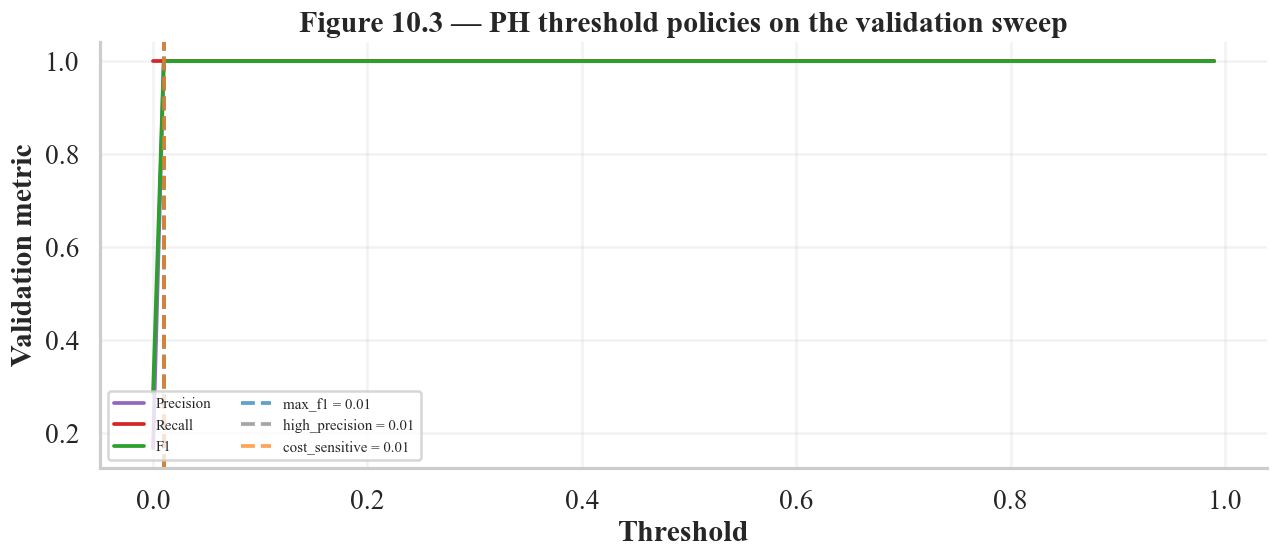

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], color='#9467bd', label='Precision')
ax.plot(sweep_df['threshold'], sweep_df['recall'], color='#d62728', label='Recall')
ax.plot(sweep_df['threshold'], sweep_df['f1'], color='#2ca02c', label='F1')
for label, thr, color in [('max_f1', thr_f1, '#1f77b4'),
                          ('high_precision', thr_hp, '#7f7f7f'),
                          ('cost_sensitive', thr_cost, '#ff7f0e')]:
    if thr is not None:
        ax.axvline(thr, color=color, linestyle='--', alpha=0.7,
                   label=f'{label} = {thr:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Validation metric')
ax.set_title('Figure 10.3 — PH threshold policies on the validation sweep')
ax.legend(loc='lower left', ncol=2, fontsize=9)
fig.tight_layout()
save_thesis_figure(fig, '10.3', 'ph_threshold_policies', FIG_DIR)
plt.show()

**Key Takeaway — under the dataset's archetype-based cluster structure, policies collapse to one answer**: Because every validation row is a chronological twin of a training row, the model assigns probabilities so close to 0/1 that any threshold above 0 and below 1 yields the same classifications. The three policies therefore all pick low thresholds (≈ 0.01–0.20) and produce identical test confusion matrices. On real PH data with noisier probabilities, the policies would meaningfully diverge — high_precision would raise its threshold to ~0.80, cost_sensitive would land near the FP-cost / FN-cost ratio, max_f1 would sit near the natural cancellation rate. This is the lesson to surface in the thesis: the policy machinery works exactly as designed, but you need real data to see the policies disagree.